# Basic Statistics

### Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

#### Importing the libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

#### Load Sales and Discounts Dataset

In [27]:
data = pd.read_csv('sales_data_with_discounts.csv')
data.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


#### Identifying the numerical columns

In [28]:
num_cols = data.select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

#### Calculate the mean, median, mode, and standard deviation for these columns.

In [29]:
for col in num_cols:
    print('\nColumns: ', col)
    print(f"mean : {data[col].mean()}")
    print(f"Median: {data[col].median()}")
    print(f"Standard Deviation: {data[col].std()}")



Columns:  Volume
mean : 5.066666666666666
Median: 4.0
Standard Deviation: 4.231602391213926

Columns:  Avg Price
mean : 10453.433333333332
Median: 1450.0
Standard Deviation: 18079.90483993645

Columns:  Total Sales Value
mean : 33812.83555555555
Median: 5700.0
Standard Deviation: 50535.07417255328

Columns:  Discount Rate (%)
mean : 15.155241895330914
Median: 16.57776564929597
Standard Deviation: 4.220602153325511

Columns:  Discount Amount
mean : 3346.499424342415
Median: 988.9337332382784
Standard Deviation: 4509.9029633539985

Columns:  Net Sales Value
mean : 30466.336131270138
Median: 4677.788059301853
Standard Deviation: 46358.656624066934


##### Interpretation:
##### The statistical measures help us understand the overall behavior of the data. The mean shows the average, the median shows the central value, the mode shows the most common value, and the standard deviation shows the spread of the data. These measures help identify patterns, variations, and possible outliers in the dataset.

## Data Visualization

### ●Histograms:

#### Plot histograms for each numerical column.

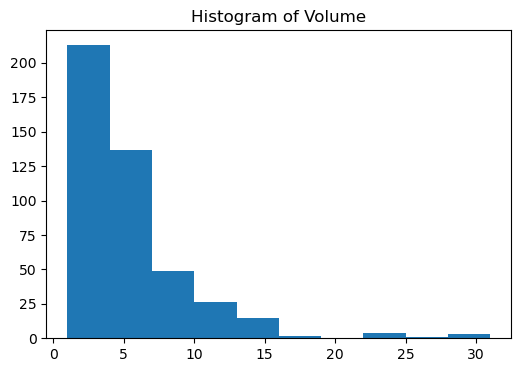

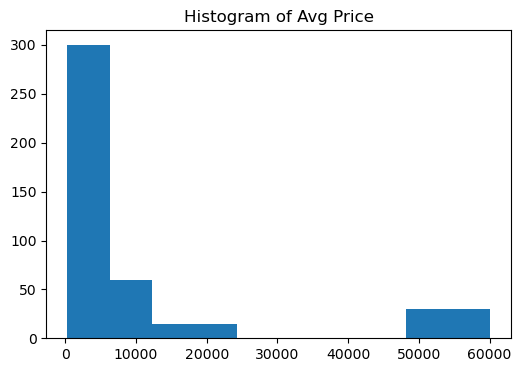

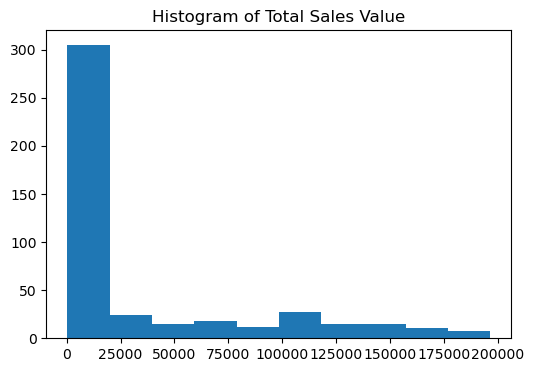

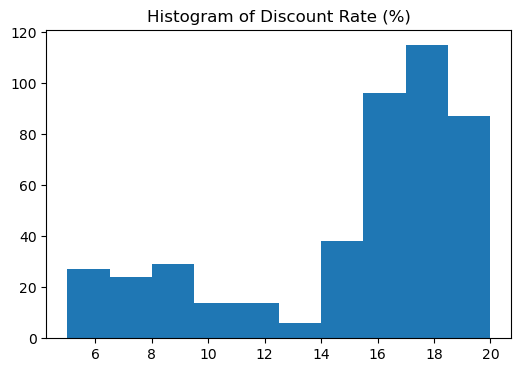

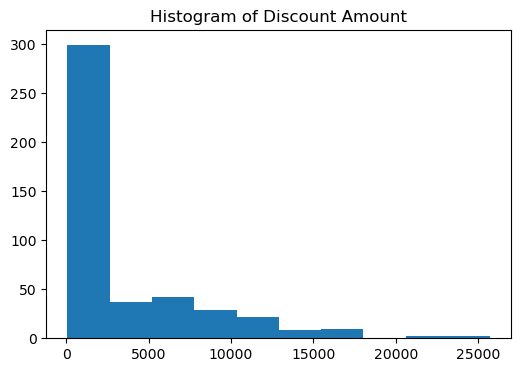

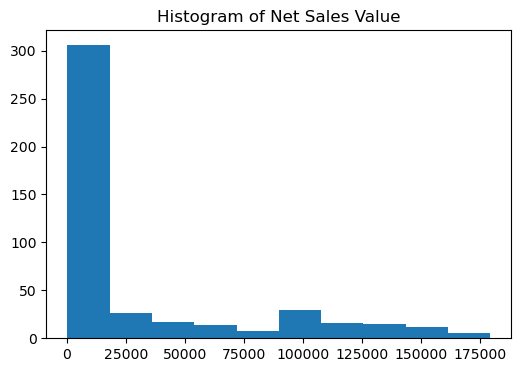

In [30]:
for col in num_cols:
    plt.figure(figsize = (6,4))
    plt.hist(data[col], bins = 10)
    plt.title(f"Histogram of {col}")
    plt.show()

##### Inference : Histograms show the distribution of numerical data and help identify skewness, spread, and possible outliers.

### Box Plots:

#### Create boxplots for numerical variables to identify outliers and the interquartile range.

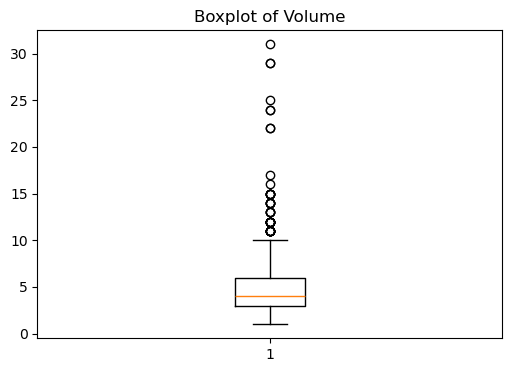

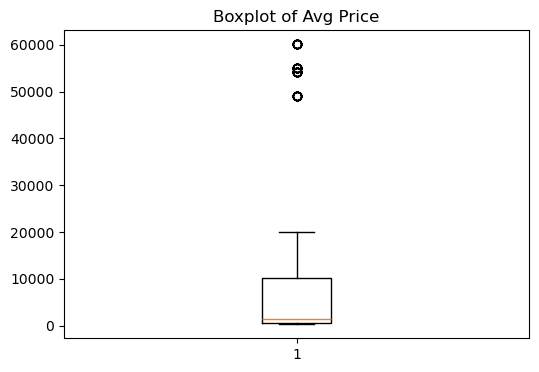

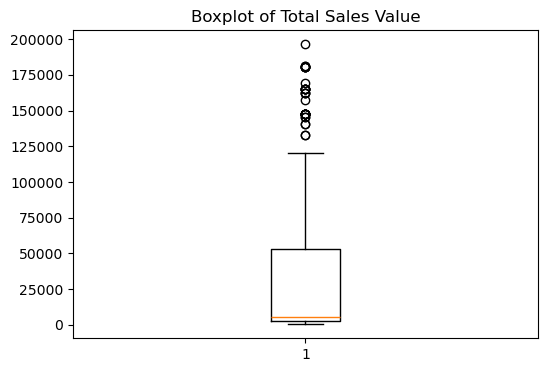

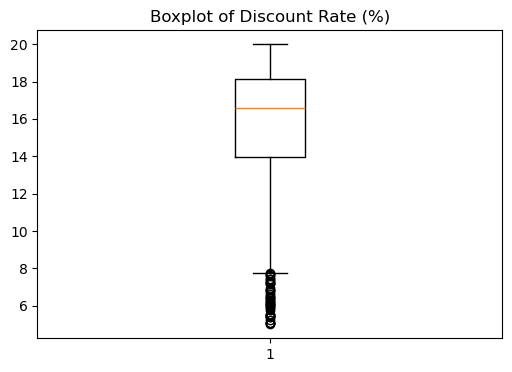

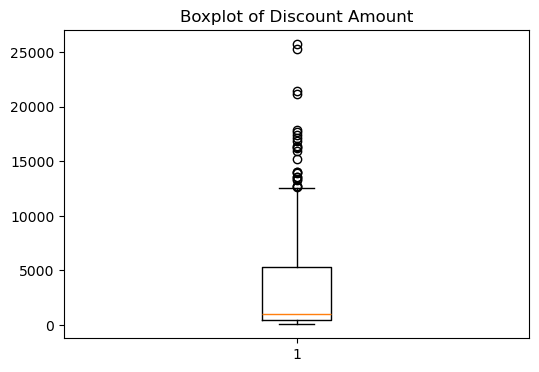

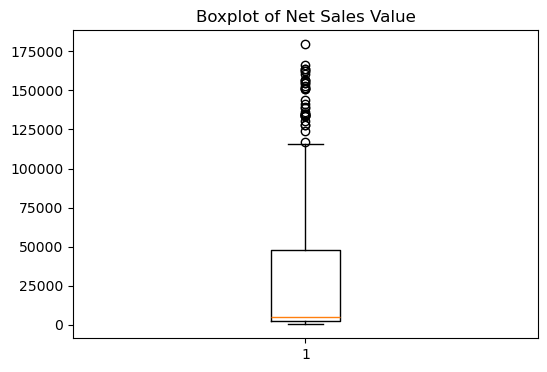

In [31]:
for col in num_cols:
    plt.figure(figsize = (6,4))
    plt.boxplot(data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

##### Findings : Boxplots help detect outliers and visualize the spread of data through the interquartile range (IQR).

### ●Bar Chart Analysis for Categorical Column:

#### Identify categorical columns in the dataset.

In [32]:
cat_cols = data.select_dtypes(include = ['object']).columns
cat_cols

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

##### Create bar charts to visualize the frequency or count of each category.

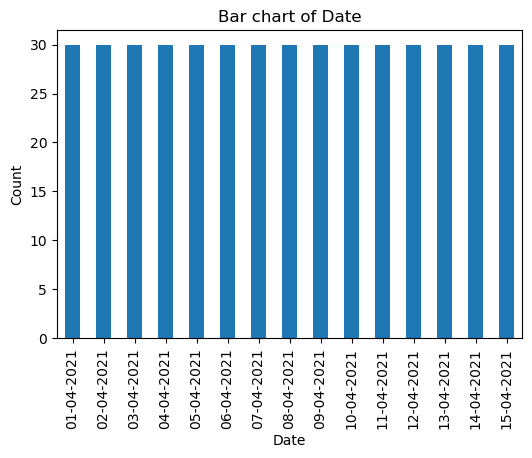

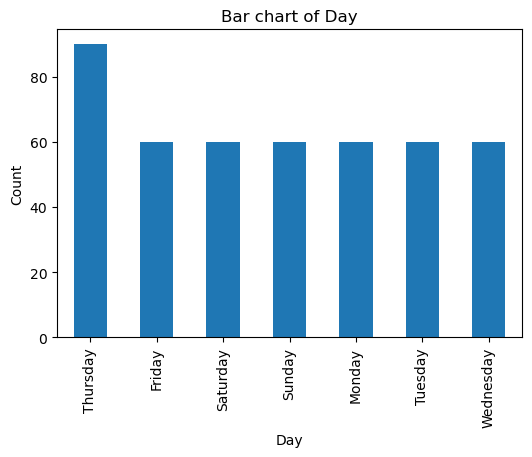

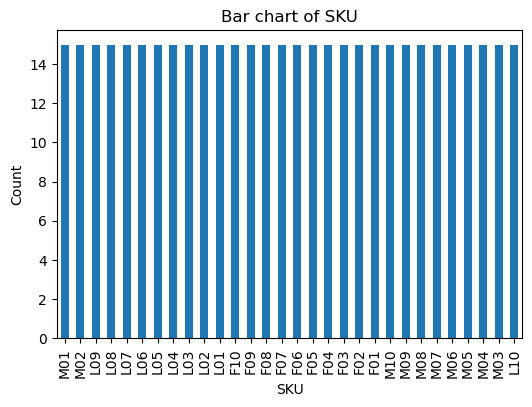

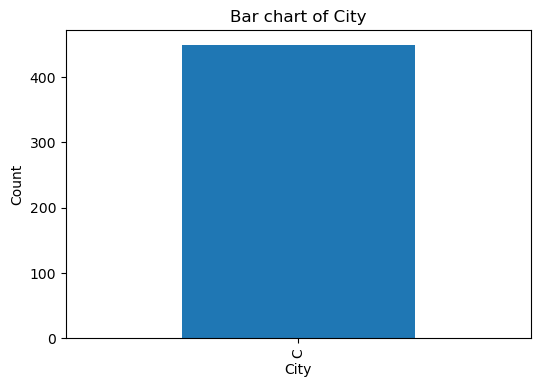

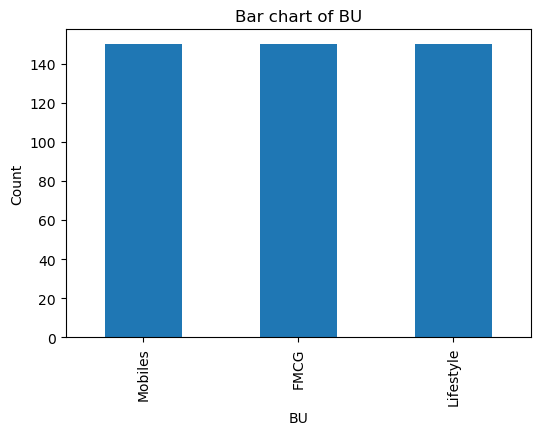

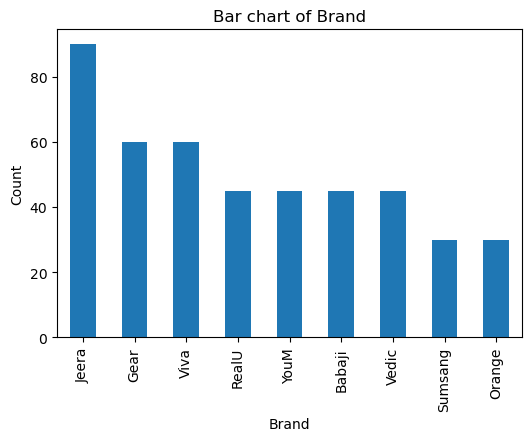

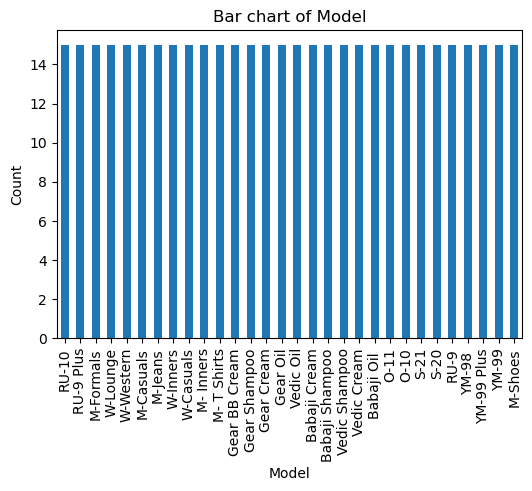

In [33]:
for col in cat_cols:
    plt.figure(figsize = (6,4))
    data[col].value_counts().plot(kind = 'bar')
    plt.title(f"Bar chart of {col}")
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

##### Insights : Bar charts show the frequency of each category and help identify the most and least common categories in the dataset.

#### Analyze the distribution of categories and provide insights

In [19]:
for col in cat_cols:
    print("\nCategory Counts for", col)
    print(data[col].value_counts())


Category Counts for Date
Date
01-04-2021    30
02-04-2021    30
03-04-2021    30
04-04-2021    30
05-04-2021    30
06-04-2021    30
07-04-2021    30
08-04-2021    30
09-04-2021    30
10-04-2021    30
11-04-2021    30
12-04-2021    30
13-04-2021    30
14-04-2021    30
15-04-2021    30
Name: count, dtype: int64

Category Counts for Day
Day
Thursday     90
Friday       60
Saturday     60
Sunday       60
Monday       60
Tuesday      60
Wednesday    60
Name: count, dtype: int64

Category Counts for SKU
SKU
M01    15
M02    15
L09    15
L08    15
L07    15
L06    15
L05    15
L04    15
L03    15
L02    15
L01    15
F10    15
F09    15
F08    15
F07    15
F06    15
F05    15
F04    15
F03    15
F02    15
F01    15
M10    15
M09    15
M08    15
M07    15
M06    15
M05    15
M04    15
M03    15
L10    15
Name: count, dtype: int64

Category Counts for City
City
C    450
Name: count, dtype: int64

Category Counts for BU
BU
Mobiles      150
FMCG         150
Lifestyle    150
Name: count, dtype: in

### Data Preprocessing

##### Check missing values

In [20]:
data.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

##### Remove duplicates

In [35]:
data = data.drop_duplicates()
print('Removed duplicates')

Removed duplicates


##### Standardize Numerical Columns

In [37]:
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

In [38]:
data.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,2.350029,Mobiles,RealU,RU-10,0.091173,2.925721,-0.830289,3.952816,2.804756
1,01-04-2021,Thursday,M02,C,1.167129,Mobiles,RealU,RU-9 Plus,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,01-04-2021,Thursday,M03,C,0.457388,Mobiles,YouM,YM-99,0.312659,1.562775,-1.351631,1.622995,1.545675
3,01-04-2021,Thursday,M04,C,0.220808,Mobiles,YouM,YM-99 Plus,0.534146,1.719276,-1.949723,1.113807,1.765810
4,01-04-2021,Thursday,M05,C,-0.488932,Mobiles,YouM,YM-98,-0.130313,-0.188452,0.673739,0.227852,-0.227595


### Conclusion

In [39]:
print("Descriptive analytics, visualization, and preprocessing completed successfully.")


Descriptive analytics, visualization, and preprocessing completed successfully.


##### Data visualization helped understand data distribution, identify outliers, and analyze category frequencies effectively.